# Anharmonic two-mode chromophore: fifth-order 2Q spectroscopy

This example calculates a fifth-order double-quantum spectrum of a small anharmonic chromophore. It demonstrates:

- a Hilbert space organized into ground, one-, two-, and three-excitation manifolds;
- explicit excitation-number raising and lowering operators;
- UFSS pathway generation for a five-interaction $\chi^{(5)}$ signal;
- coherence-order-resolved spectra;
- convergence with respect to the excitation-manifold cutoff; and
- mode-resolved detection from the same propagated pathway states.

Natural units are used, with $\hbar=1$. Energies are in eV and times are in eV$^{-1}$.


In [1]:
import os

# OpenBLAS parallelizes matrix operations above a size threshold that this
# model crosses at N_max = 3 (Liouville dimension 100). For matrices this
# small the thread synchronization cost dominates: an unconstrained inverse
# is ~15x slower than a single-threaded one. These variables are read when
# numpy loads its BLAS, so they must be set before the import below.
for _thread_variable in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
):
    os.environ.setdefault(_thread_variable, "1")


import matplotlib.pyplot as plt
import numpy as np
import ufss
from qudpy_fdgf import (
    EigenbasisKModel,
    SpectroscopySolver,
    standard_nq_protocol,
    translate_ufss_diagrams,
)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})


## 1. Truncated bosonic model

The double-quantum interval itself requires at most two excitations. A complete fifth-order pathway can nevertheless reach the three-excitation manifold before detection. The production calculation therefore uses

$$n_h+n_l\leq 3.$$

The lower-manifold eigenvalues remain independent of this cutoff because the Hamiltonian conserves total excitation number. The three-excitation manifold is required for the amplitudes and for the final $|3\mathrm{exc}\rangle\langle2\mathrm{exc}|$ emission coherences.


In [2]:
omega_h = 1.53
omega_l = 1.58
coupling = 0.010
mu_h = 1.0
mu_l = 0.30
U_hh = -0.020
U_ll = -0.020
U_hl = 0.030

fixed_delays = {"t1": 2.0, "t3": 2.0, "t4": 2.0}
phase_discrimination = [(0, 1), (0, 1), (1, 0), (1, 0), (1, 0)]

omega_2q = np.linspace(-3.20, -2.99, 151)
omega_emit = np.linspace(1.42, 1.66, 151)


In [3]:
def make_basis_operators(maximum_manifold):
    basis = tuple(
        (n_h, total - n_h)
        for total in range(maximum_manifold + 1)
        for n_h in range(total, -1, -1)
    )
    basis_index = {state: index for index, state in enumerate(basis)}
    dimension = len(basis)

    b_h = np.zeros((dimension, dimension), dtype=complex)
    b_l = np.zeros_like(b_h)
    for source_index, (n_h, n_l) in enumerate(basis):
        if n_h > 0:
            b_h[basis_index[(n_h - 1, n_l)], source_index] = np.sqrt(n_h)
        if n_l > 0:
            b_l[basis_index[(n_h, n_l - 1)], source_index] = np.sqrt(n_l)
    return basis, b_h, b_l


def calculate_case(
    maximum_manifold,
    eta,
    omega_2q_axis=omega_2q,
    omega_emit_axis=omega_emit,
    anharmonicities=(U_hh, U_ll, U_hl),
):
    basis, b_h, b_l = make_basis_operators(maximum_manifold)
    dimension = len(basis)
    identity = np.eye(dimension, dtype=complex)
    number_h = b_h.conj().T @ b_h
    number_l = b_l.conj().T @ b_l
    local_U_hh, local_U_ll, local_U_hl = anharmonicities

    H_site = (
        omega_h * number_h
        + omega_l * number_l
        + coupling * (b_h.conj().T @ b_l + b_l.conj().T @ b_h)
        + 0.5 * local_U_hh * number_h @ (number_h - identity)
        + 0.5 * local_U_ll * number_l @ (number_l - identity)
        + local_U_hl * number_h @ number_l
    )

    J_plus = mu_h * b_h.conj().T + mu_l * b_l.conj().T
    J_minus = J_plus.conj().T
    interaction_site = J_plus + J_minus
    polarization_h = mu_h * (b_h + b_h.conj().T)
    polarization_l = mu_l * (b_l + b_l.conj().T)

    model = EigenbasisKModel(
        H_site,
        interaction_site,
        j_plus_array=J_plus,
        j_minus_array=J_minus,
        detection_op_array=interaction_site,
        observable_op_arrays={
            "polarization": interaction_site,
            "polarization_h": polarization_h,
            "polarization_l": polarization_l,
        },
    )

    # The backend default of 32 cached resolvents is far below the working set
    # of a 151x151 frequency scan, which forces repeated dense inversions.
    solver = SpectroscopySolver(
        backend="dense", eta=eta, max_cache_entries=4096
    )
    solver.feed_model(model)

    diagram_generator = ufss.DiagramGenerator(detection_type="polarization")
    diagram_generator.set_phase_discrimination(phase_discrimination)
    diagram_generator.maximum_manifold = maximum_manifold
    diagram_generator.efield_times = [np.array([0.0, 0.0])] * 5
    ufss_diagrams = diagram_generator.get_diagrams(np.arange(5, dtype=float))
    pathways = translate_ufss_diagrams(ufss_diagrams, component="chi5_2q")
    solver.set_pathways(pathways)

    protocol = standard_nq_protocol(
        order=2,
        nq_interval=2,
        detection_interval=5,
        n_interactions=5,
        nq_axis="omega_2q",
        detection_axis="omega_emit",
    )
    result = solver.generate_nq_spectrum(
        2,
        protocol,
        axes={"omega_2q": omega_2q_axis, "omega_emit": omega_emit_axis},
        fixed_coordinates=fixed_delays,
        pathways=pathways,
        observables=("polarization_h", "polarization_l"),
    )

    labels = {
        pathway.name: tuple(interaction.label for interaction in pathway.interactions)
        for pathway in pathways
    }
    return {
        "basis": basis,
        "H": H_site,
        "energies": np.linalg.eigvalsh(H_site),
        "model": model,
        "solver": solver,
        "pathways": pathways,
        "pathway_labels": labels,
        "protocol": protocol,
        "result": result,
        "omega_2q": np.asarray(omega_2q_axis),
        "omega_emit": np.asarray(omega_emit_axis),
        "eta": float(eta),
        "maximum_manifold": int(maximum_manifold),
    }


## 2. Production calculations

Two spectra are calculated on the same $151\times151$ grid. The first uses the production broadening $\eta=8$ meV; the second uses $\eta=2$ meV to expose the individual resonance families. Both calculations retain the full three-excitation manifold and the seven UFSS pathways.


In [4]:
case_eta8 = calculate_case(3, 0.008)
case_eta2 = calculate_case(3, 0.002)

assert len(case_eta8["basis"]) == 10
assert len(case_eta8["pathways"]) == 7
assert all(pathway.coherence_orders == (-1, -2, -1, 0, 1) for pathway in case_eta8["pathways"])
assert np.allclose(case_eta8["result"].components["+2Q"], 0.0)

energies = case_eta8["energies"]
epsilon = energies[1:3]
E_two = energies[3:6]
E_three = energies[6:10]

peak_index = np.unravel_index(
    np.argmax(np.abs(case_eta8["result"].components["chi5_2q"])),
    case_eta8["result"].shape,
)
peak_coordinate = (
    omega_2q[peak_index[0]],
    omega_emit[peak_index[1]],
)

print("Ordered basis:", case_eta8["basis"])
print("One-excitation energies:", np.round(epsilon, 6))
print("Two-excitation energies:", np.round(E_two, 6))
print("Three-excitation energies:", np.round(E_three, 6))
print("Number of pathways:", len(case_eta8["pathways"]))
print("Strongest eta=8 meV coordinate:", tuple(np.round(peak_coordinate, 6)))


Ordered basis: ((0, 0), (1, 0), (0, 1), (2, 0), (1, 1), (0, 2), (3, 0), (2, 1), (1, 2), (0, 3))
One-excitation energies: [1.528074 1.581926]
Two-excitation energies: [3.038001 3.126961 3.155038]
Three-excitation energies: [4.528    4.669549 4.680921 4.74153 ]
Number of pathways: 7
Strongest eta=8 meV coordinate: (np.float64(-3.0376), np.float64(1.5096))


## 3. Fifth-order 2Q map at $\eta=8$ meV

The following figure shows only the production spectrum. It is not concatenated with the narrow-broadening control, so its axes, normalization, and physical assignment remain readable on their own.


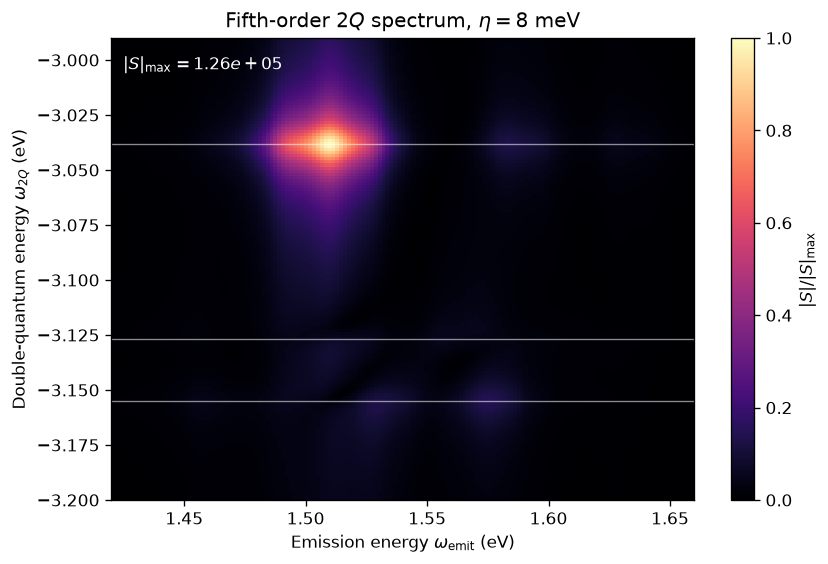

In [5]:
def plot_abs_map(case, title):
    spectrum = np.abs(case["result"].components["chi5_2q"])
    maximum = np.max(spectrum)
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    image = ax.imshow(
        spectrum / maximum,
        origin="lower",
        aspect="auto",
        extent=(
            case["omega_emit"][0], case["omega_emit"][-1],
            case["omega_2q"][0], case["omega_2q"][-1],
        ),
        cmap="magma",
        vmin=0.0,
        vmax=1.0,
    )
    for energy in E_two:
        ax.axhline(-energy, color="white", lw=0.8, alpha=0.55)
    ax.set_xlabel(r"Emission energy $\omega_{\mathrm{emit}}$ (eV)")
    ax.set_ylabel(r"Double-quantum energy $\omega_{2Q}$ (eV)")
    ax.set_title(title)
    ax.text(
        0.02, 0.96, rf"$|S|_{{\max}}={maximum:.2e}$",
        transform=ax.transAxes, va="top", color="white",
    )
    fig.colorbar(image, ax=ax, label=r"$|S|/|S|_{\max}$")
    fig.tight_layout()
    plt.show()
    return maximum

maximum_eta8 = plot_abs_map(case_eta8, r"Fifth-order $2Q$ spectrum, $\eta=8$ meV")


### Analysis of the $\eta=8$ meV map

The dominant feature is centred near $(-E_1,E_1-\varepsilon_1)=(-3.038,1.510)$ eV. The vertical resonance coordinate identifies the lowest two-excitation state, whereas the emission coordinate corresponds to a $|2\mathrm{exc}\rangle\langle1\mathrm{exc}|$ coherence. At this broadening, neighbouring poles overlap and their complex pathway amplitudes interfere; the maximum should therefore be described as consistent with this assignment rather than as an independent measurement of the exact eigenenergies.

For a state dominated by a diagonal pair $(i,i)$, the harmonic reference is $\omega_{\mathrm{emit}}=-\omega_{2Q}/2$. The displacement of the dominant feature from that line is $\Delta_{1;11}/2\simeq-9.07$ meV. This diagonal reference does not apply to mixed pairs $(i,j)$ with $i\neq j$.


## 4. Resolved resonance structure at $\eta=2$ meV

Reducing the phenomenological resolvent broadening separates features that overlap in the production spectrum. This control is displayed as a separate figure with its own normalization.


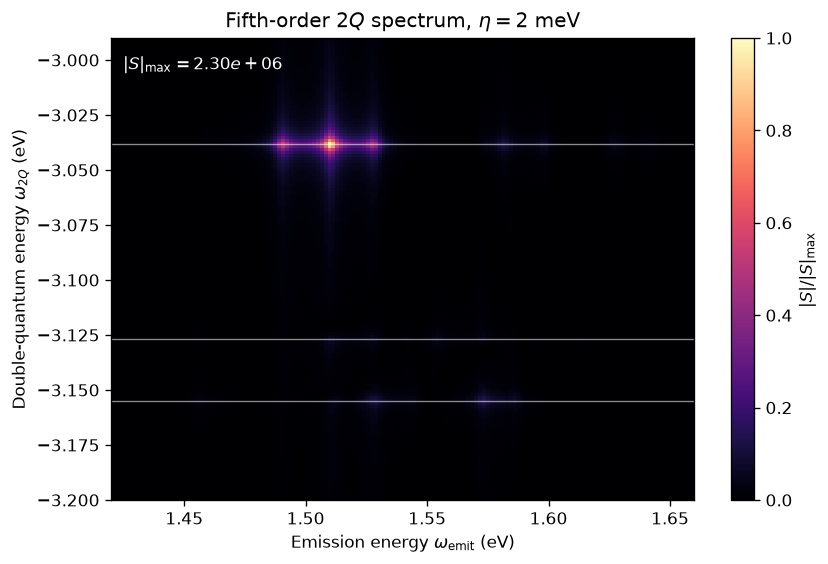

Peak-height ratio eta=2 / eta=8 meV: 18.274


In [6]:
maximum_eta2 = plot_abs_map(case_eta2, r"Fifth-order $2Q$ spectrum, $\eta=2$ meV")
eta_peak_ratio = maximum_eta2 / maximum_eta8
print(f"Peak-height ratio eta=2 / eta=8 meV: {eta_peak_ratio:.3f}")


### Analysis of the $\eta=2$ meV map

The three horizontal groups align with the two-excitation energies $-E_k$. Along the emission axis, the selected pathways can end in three kinds of $q=+1$ coherence:

$$|1\mathrm{exc}\rangle\langle g|,\qquad
|2\mathrm{exc}\rangle\langle1\mathrm{exc}|,\qquad
|3\mathrm{exc}\rangle\langle2\mathrm{exc}|.$$

Their pole frequencies are respectively $\varepsilon_j$, $E_k-\varepsilon_j$, and $E_m^{(3)}-E_k$. Representatives of all three families become visible at the smaller broadening.

The fourfold reduction of $\eta$ increases the maximum by a factor close to the $\eta^{-2}$ scaling expected when the two frequency-domain resolvents are simultaneously near resonance. Deviations from the ideal factor of 16 arise from finite-grid sampling, overlapping poles, and pathway interference; this is not the scaling of a single isolated pole.


## 5. Pathway completeness and the excitation ceiling

The next figure isolates the eight binary orderings of the last three interactions. It directly separates the ceiling-limited all-$K_u$ pathway from the floor-limited all-$B_d$ ordering.


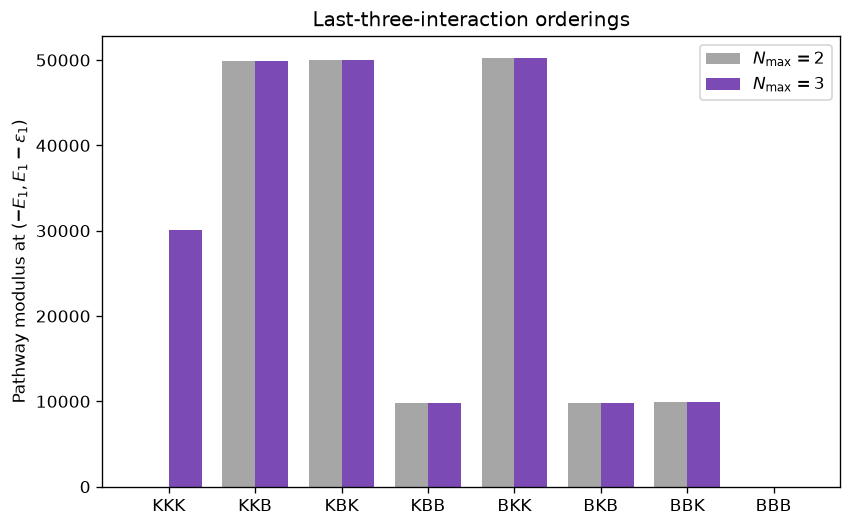

Orderings bit-identical at both truncations (nonzero): 6 -> KKB, KBK, KBB, BKK, BKB, BBK
all-Ku (KKK): N_max=2 -> 0.000e+00, N_max=3 -> 3.012e+04
Orderings never generated by the diagram generator: ['BBB']


In [7]:
case_n2_eta8 = calculate_case(2, 0.008)
all_orderings = ("KKK", "KKB", "KBK", "KBB", "BKK", "BKB", "BBK", "BBB")

def ordering_key(labels):
    return "".join("K" if label == "Ku" else "B" for label in labels[2:])

def pathway_amplitudes_at(case, omega_2q_value, omega_emit_value):
    row = int(np.argmin(np.abs(case["omega_2q"] - omega_2q_value)))
    column = int(np.argmin(np.abs(case["omega_emit"] - omega_emit_value)))
    values = {key: 0.0 for key in all_orderings}
    for name, labels in case["pathway_labels"].items():
        values[ordering_key(labels)] = abs(case["result"].pathways[name][row, column])
    return values

amplitudes_n2 = pathway_amplitudes_at(case_n2_eta8, -E_two[0], E_two[0] - epsilon[0])
amplitudes_n3 = pathway_amplitudes_at(case_eta8, -E_two[0], E_two[0] - epsilon[0])

x = np.arange(len(all_orderings))
width = 0.38
fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.bar(x - width / 2, [amplitudes_n2[key] for key in all_orderings], width, label=r"$N_{\max}=2$", color="0.65")
ax.bar(x + width / 2, [amplitudes_n3[key] for key in all_orderings], width, label=r"$N_{\max}=3$", color="#7b4ab5")
ax.set_xticks(x, all_orderings)
ax.set_ylabel(r"Pathway modulus at $(-E_1,E_1-\varepsilon_1)$")
ax.set_title("Last-three-interaction orderings")
ax.legend()
fig.tight_layout()
plt.show()

generated_orderings = {
    ordering_key(labels) for labels in case_eta8["pathway_labels"].values()
}
missing_orderings = [k for k in all_orderings if k not in generated_orderings]
identical_nonzero = [
    key
    for key in all_orderings
    if amplitudes_n2[key] == amplitudes_n3[key] and amplitudes_n3[key] > 0.0
]
print(
    f"Orderings bit-identical at both truncations (nonzero): "
    f"{len(identical_nonzero)} -> {', '.join(identical_nonzero)}"
)
print(
    f"all-Ku (KKK): N_max=2 -> {amplitudes_n2['KKK']:.3e}, "
    f"N_max=3 -> {amplitudes_n3['KKK']:.3e}"
)
print(f"Orderings never generated by the diagram generator: {missing_orderings}")


### Analysis of pathway completeness

Six pathways are identical to numerical precision at the two truncations because their density-matrix trajectories never leave the $N\leq2$ blocks. The all-$K_u$ ordering reaches the three-excitation manifold and is therefore exactly suppressed at $N_{\max}=2$ but finite at $N_{\max}=3$. The all-$B_d$ ordering would lower the bra below the ground state on its third $B_d$ interaction and remains zero independently of the upper cutoff.

Thus, the seven UFSS pathways at $N_{\max}=3$ form the complete set for the selected fifth-order phase signature. The distinction follows from the ladder boundaries encoded by the transition operators; it is not an additional rule imposed during propagation.


## 6. Spectral consequence of truncating at two excitations

A one-dimensional cut makes the missing three-excitation resonance easier to identify than a multi-panel comparison.


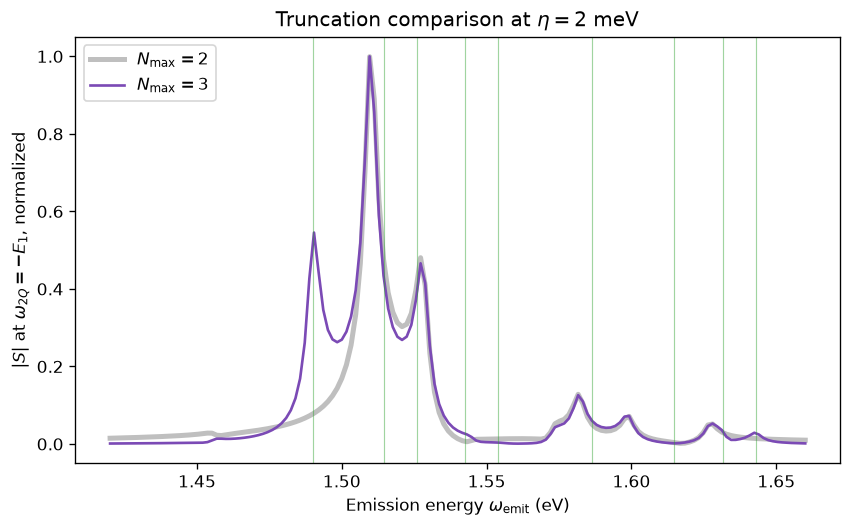

eta=8 meV: N_max=2 peak deviation +12.59 %, complex spectra differ by 63.5 % of the converged maximum
eta=2 meV: N_max=2 peak deviation -0.08 %, complex spectra differ by 53.4 % of the converged maximum


In [8]:
case_n2_eta2 = calculate_case(2, 0.002)
row_n2 = int(np.argmin(np.abs(case_n2_eta2["omega_2q"] + E_two[0])))
row_n3 = int(np.argmin(np.abs(case_eta2["omega_2q"] + E_two[0])))
cut_n2 = np.abs(case_n2_eta2["result"].components["chi5_2q"][row_n2])
cut_n3 = np.abs(case_eta2["result"].components["chi5_2q"][row_n3])
cut_scale = np.max(cut_n3)

fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.plot(omega_emit, cut_n2 / cut_scale, lw=3.0, color="0.75", label=r"$N_{\max}=2$")
ax.plot(omega_emit, cut_n3 / cut_scale, lw=1.6, color="#7b4ab5", label=r"$N_{\max}=3$")
for transition in (E_three[:, None] - E_two[None, :]).ravel():
    if omega_emit[0] <= transition <= omega_emit[-1]:
        ax.axvline(transition, color="#2ca02c", lw=0.7, alpha=0.45)
ax.set_xlabel(r"Emission energy $\omega_{\mathrm{emit}}$ (eV)")
ax.set_ylabel(r"$|S|$ at $\omega_{2Q}=-E_1$, normalized")
ax.set_title(r"Truncation comparison at $\eta=2$ meV")
ax.legend()
fig.tight_layout()
plt.show()

# --- Truncation error quoted in the manuscript (Scope) ---
def truncation_metrics(case_n2, case_n3):
    spectrum_n2 = case_n2["result"].components["chi5_2q"]
    spectrum_n3 = case_n3["result"].components["chi5_2q"]
    converged_maximum = np.max(np.abs(spectrum_n3))
    peak_deviation = np.max(np.abs(spectrum_n2)) / converged_maximum - 1.0
    complex_difference = (
        np.max(np.abs(spectrum_n2 - spectrum_n3)) / converged_maximum
    )
    return peak_deviation, complex_difference


for label, case_n2, case_n3 in (
    ("eta=8 meV", case_n2_eta8, case_eta8),
    ("eta=2 meV", case_n2_eta2, case_eta2),
):
    peak_deviation, complex_difference = truncation_metrics(case_n2, case_n3)
    print(
        f"{label}: N_max=2 peak deviation {100 * peak_deviation:+.2f} %, "
        f"complex spectra differ by {100 * complex_difference:.1f} % "
        f"of the converged maximum"
    )

### Analysis of the truncation cut

The largest difference is concentrated near the $E_m^{(3)}-E_k$ transition marked by the green guides, where the $N_{\max}=3$ calculation contains a resonance that is absent at $N_{\max}=2$. The six pathways common to both truncations are identical to numerical precision, but the total spectra need not coincide elsewhere because the additional all-$K_u$ pathway has finite spectral tails and interferes with the common pathways.

The truncation therefore removes genuine spectral structure rather than producing a uniform rescaling. Because pathway amplitudes are complex, omitting this resonance can also modify the dominant peak through interference when the broadening is large enough for neighbouring features to overlap.


## 7. Mode-resolved detection

The total and mode-resolved polarizations are now shown in a dedicated figure. All curves are extracted from the same propagated pathway states.


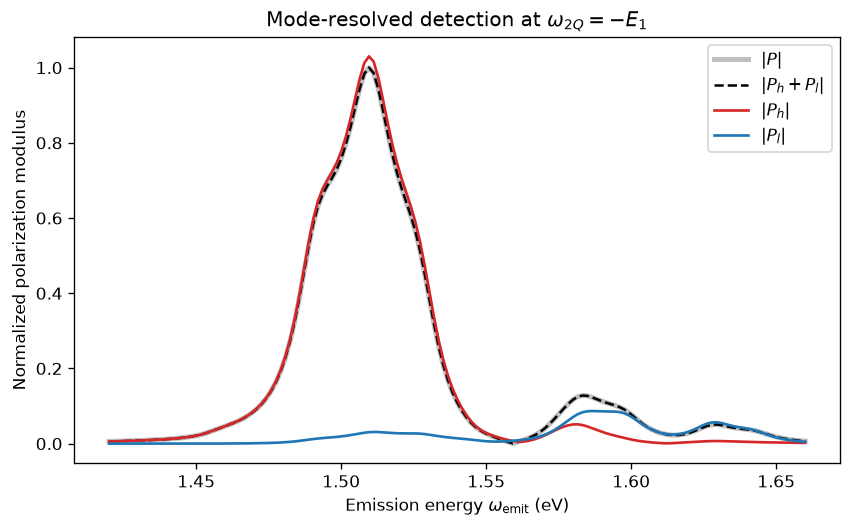

Relative mode-sum residual: 3.487e-16


In [9]:
row_eta8 = int(np.argmin(np.abs(omega_2q + E_two[0])))
total = case_eta8["result"].components["chi5_2q"][row_eta8]
polarization_h = case_eta8["result"].observable_components["polarization_h"]["-2Q"][row_eta8]
polarization_l = case_eta8["result"].observable_components["polarization_l"]["-2Q"][row_eta8]
mode_sum = polarization_h + polarization_l
mode_scale = np.max(np.abs(total))
mode_residual = np.max(np.abs(total - mode_sum)) / mode_scale

fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.plot(omega_emit, np.abs(total) / mode_scale, lw=3.0, color="0.75", label=r"$|P|$")
ax.plot(omega_emit, np.abs(mode_sum) / mode_scale, "k--", lw=1.5, label=r"$|P_h+P_l|$")
ax.plot(omega_emit, np.abs(polarization_h) / mode_scale, color="#d62728", lw=1.6, label=r"$|P_h|$")
ax.plot(omega_emit, np.abs(polarization_l) / mode_scale, color="#1f77b4", lw=1.6, label=r"$|P_l|$")
ax.set_xlabel(r"Emission energy $\omega_{\mathrm{emit}}$ (eV)")
ax.set_ylabel(r"Normalized polarization modulus")
ax.set_title(r"Mode-resolved detection at $\omega_{2Q}=-E_1$")
ax.legend()
fig.tight_layout()
plt.show()
print(f"Relative mode-sum residual: {mode_residual:.3e}")


### Analysis of the detection channels

The identity $P=P_h+P_l$ is reproduced to numerical precision and checks that additional observables reuse the same propagated density-matrix state. Near the dominant feature, the detected polarization is governed mainly by the contribution associated with the more strongly dipole-coupled local mode $h$, for which $\mu_h>\mu_l$.

This is a decomposition of the complex detection amplitude, not a population measurement of the two-excitation eigenstate. In particular, the relative sizes of $P_h$ and $P_l$ depend on the chosen local-mode basis, the dipole coefficients, and their interference phase.


## 8. Harmonic-limit cancellation

The final validation sets all anharmonicities to zero while retaining the complete seven-pathway, three-manifold calculation. A coarse grid is sufficient because the test concerns cancellation between pathways rather than peak localization.


In [10]:
harmonic_omega_2q = np.linspace(-3.20, -2.99, 9)
harmonic_omega_emit = np.linspace(1.42, 1.66, 9)
harmonic_case = calculate_case(
    3,
    0.008,
    omega_2q_axis=harmonic_omega_2q,
    omega_emit_axis=harmonic_omega_emit,
    anharmonicities=(0.0, 0.0, 0.0),
)
harmonic_total = harmonic_case["result"].components["chi5_2q"]
pathway_values = [
    np.asarray(values) for values in harmonic_case["result"].pathways.values()
]
largest_pathway = max(np.max(np.abs(values)) for values in pathway_values)
sum_of_pathway_moduli = np.max(sum(np.abs(values) for values in pathway_values))
harmonic_cancellation = np.max(np.abs(harmonic_total)) / largest_pathway
harmonic_cancellation_sum = (
    np.max(np.abs(harmonic_total)) / sum_of_pathway_moduli
)
print(f"Maximum total / maximum individual pathway: {harmonic_cancellation:.3e}")
print(f"Maximum total / sum of pathway moduli: {harmonic_cancellation_sum:.3e}")
assert harmonic_cancellation < 1e-10


Maximum total / maximum individual pathway: 2.551e-13
Maximum total / sum of pathway moduli: 6.377e-14


### Analysis of the harmonic limit

The seven fifth-order pathways cancel to numerical precision when $U_{hh}=U_{ll}=U_{hl}=0$, as expected for a linearly driven harmonic system. The cutoff at $N_{\max}=3$ does not generate an artificial fifth-order response because no selected pathway requires a four-excitation state.

By contrast, truncating at $N_{\max}=2$ removes the all-$K_u$ pathway and prevents this cancellation. This provides an independent reason, in addition to the missing $E_m^{(3)}-E_k$ resonance, for retaining the three-excitation manifold.


## 9. Reusable broadening scan

The public `loop` function provides a stable entry point for repeating the two broadening cases. The production results already calculated above are reused rather than recomputed.


In [11]:
SCAN_VALUES = {"eta": {"values": (0.008, 0.002), "unit": "eV"}}
_ETA_RESULTS = {0.008: case_eta8, 0.002: case_eta2}


def loop(scan_name, indices=None):
    if scan_name not in SCAN_VALUES:
        raise KeyError(f"Unknown scan_name {scan_name!r}; available: {tuple(SCAN_VALUES)}")
    values = SCAN_VALUES[scan_name]["values"]
    if indices is None:
        indices = range(len(values))
    outputs = []
    for index in indices:
        index = int(index)
        if index < 0 or index >= len(values):
            raise IndexError(f"{scan_name}[{index}] is outside 0..{len(values)-1}")
        value = values[index]
        outputs.append(_ETA_RESULTS[value])
    return outputs


print("Available scan: loop('eta', indices=None)")


Available scan: loop('eta', indices=None)
